In [129]:
# Objective:

# 1.	Make the learner load the data using pandas.
# 2.	Create new columns in dataset from existing columns.
# 3.	Use pandas to answer questions of interest.
# 4.	Plot variables of interest.
# Dataset used: Prisoners dataset sourced from data.gov.in
# Questions:


# 1.	Data Loading:
# a.	Load the dataset “prisoners.csv” using pandas and display the first and last five rows in the dataset.
# [Hint: Refer to read_csv, head and tail methods in pandas]
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
data=pd.read_csv("/content/prisoners.csv")
print(data.head(5))
print(data.tail(5))

,STATE/UT,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course
30,D & N Haveli,2013,0,0,0,0
31,Daman & Diu,2013,0,0,0,0
32,Delhi,2013,1458,1187,908,174
33,Lakshadweep,2013,0,0,0,0
34,Pondicherry,2013,0,0,0,0


In [139]:
# b.	Use describe method in pandas and find out the number of columns. Can you say something about those rows who have zero inmates?
# [Hint: Use the loc attribute of dataframe combined with conditional checks]
data.describe()

,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course
count,35.0,35.000000,35.000000,35.000000,35.000000
mean,2013.0,1057.914286,1534.857143,237.457143,210.171429
std,0.0,2078.196777,3022.110503,375.614191,359.117340
min,2013.0,0.000000,0.000000,0.000000,0.000000
25%,2013.0,0.000000,6.500000,2.000000,0.000000
50%,2013.0,167.000000,237.000000,33.000000,38.000000
75%,2013.0,1294.500000,1733.500000,234.500000,227.500000
max,2013.0,9480.000000,13758.000000,1353.000000,1417.000000


In [138]:
zero_inmates=data.loc[data['No. of Inmates benefitted by Elementary Education']==0]
zero_inmates

,STATE/UT,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course
1,Arunachal Pradesh,2013,0,0,0,0
15,Manipur,2013,0,0,0,0
17,Mizoram,2013,0,25,18,0
18,Nagaland,2013,0,0,0,0
22,Sikkim,2013,0,0,0,0
29,Chandigarh,2013,0,265,85,0
30,D & N Haveli,2013,0,0,0,0
31,Daman & Diu,2013,0,0,0,0
33,Lakshadweep,2013,0,0,0,0
34,Pondicherry,2013,0,0,0,0


In [143]:
# 2.	Data Manipulation:

# a.	Create a new column -’total_benefitted’ that is a sum of inmates benefitted through all modes.
# [Hint: Use sum method with appropriate axis]
data['total_benefitted']=data.iloc[:,2:].sum(axis=1)
data.head()


,STATE/UT,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course,total_benefitted
0,Andhra Pradesh,2013,9480,13758,672,170,72240
1,Arunachal Pradesh,2013,0,0,0,0,0
2,Assam,2013,676,750,14,30,4410
3,Bihar,2013,1693,3013,125,1417,18744
4,Chhatisgarh,2013,1664,1803,192,103,11286


In [144]:
# Create a new Data Frame to Store column-wise total. Name New Data Frame as prisoners_total
prisoners_total=data

In [153]:
# b.	Create a new row - “totals” that is the sum of all inmates benefitted through each mode across all states.
data.loc['totals']=data.iloc[:,2:].sum()
data.tail(5)

,STATE/UT,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course,total_benefitted
31,Daman & Diu,2013.0,0.0,0.0,0.0,0.0,0.0
32,Delhi,2013.0,1458.0,1187.0,908.0,174.0,11181.0
33,Lakshadweep,2013.0,0.0,0.0,0.0,0.0,0.0
34,Pondicherry,2013.0,0.0,0.0,0.0,0.0,0.0
totals,NaN,NaN,37027.0,53720.0,8311.0,7356.0,319242.0


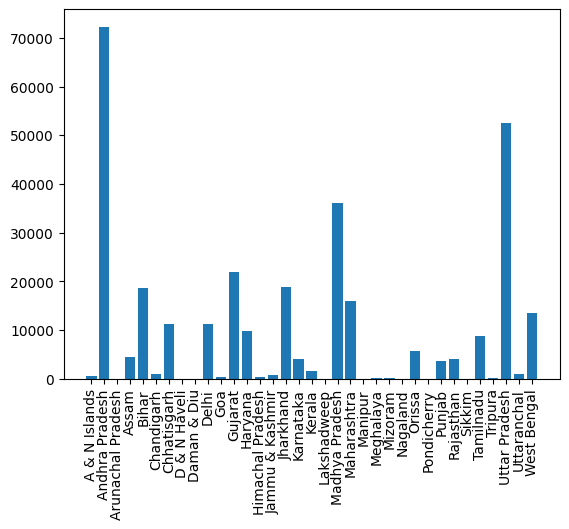

In [163]:
# 3.	Plotting:

# a.	Make a bar plot with each state name on the x -axis and their total benefitted inmates as their bar heights. Which state has the maximum number of beneficiaries?
# [Hint: Use bar method of pyplot]
data_states=data.groupby('STATE/UT')['total_benefitted'].sum()
plt.bar(x=data_states.index, height=data_states.values)
plt.xticks(rotation=90)
plt.show()

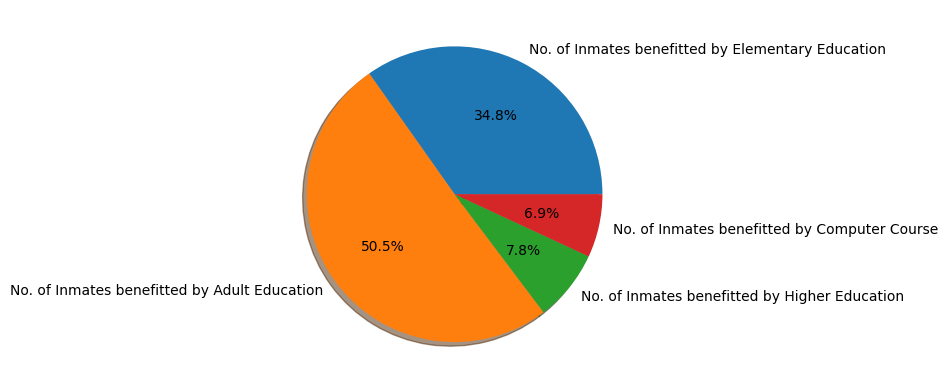

In [191]:
# b.	Make a pie chart that depicts the ratio among different modes of benefits.
# [Hint: Use pie method of pyplot]
labels=data.columns[2:-1]
values=data.iloc[-1][2:-1].values
plt.pie(values,labels=labels,autopct='%1.1f%%', shadow=True)
plt.show()